# NGC 4848

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
from pangal.region import Region
from pangal.plot import Point, Contours
from pangal.photometry_table import PhotometryTable, PhotometryCatalog

import warnings
warnings.simplefilter("ignore")


In [2]:
directory = '/home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/'


muse_file =  glob.glob(directory+'*muse*.fits')
spitzer_files = glob.glob(directory+'*SPITZER_*.fits')
sdss_files = glob.glob(directory+'*sdss*.fits')
wise_files = glob.glob(directory+'*WISE*.fits')
hershel_files = glob.glob(directory+'*hpacs*.fits')
twomass_files = glob.glob(directory+'*2mass*.fits')
hst_files = glob.glob(directory+'*hst*.fits')
galex_files = ['/home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_nuv.fits','/home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_fuv.fits']

files_list = galex_files + sdss_files + twomass_files + spitzer_files + hershel_files + hst_files + muse_file # + wise_files 



In [3]:
print(muse_file)

['/home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/NGC4848_muse_cut.fits']


In [4]:
from astropy.io import fits
with fits.open('/home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/NGC4848_muse_cut.fits') as hdul:
    hdul.info()
    data = hdul[1].data

Filename: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/NGC4848_muse_cut.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      47   ()      
  1  DATA          1 ImageHDU        40   (290, 395, 3400)   float32   
  2  STAT          1 ImageHDU        40   (290, 395, 3400)   float32   


In [5]:
z_true =  0.023974 
ra_center, dec_center = 194.523241, 28.242570

distance = 104 # Mpc

M_star = 10**10.32
#V = Md_to_Vc(M_star)

#print(V)
#spin = 0.05
#print(Rd(V,spin))

# Convert angular scale to physical scale
from astropy.cosmology import Planck18 as cosmo
z_Coma = 0.023513
D_A = cosmo.angular_diameter_distance(z_Coma).to('pc').value

theta_deg_1kpc = 1e3 / D_A / (np.pi / 180)               # Convert 1 kpc in deg
theta_arcsec_1kpc = 1e3 / D_A / (np.pi / 648000)         # Convert 1 kpc in arcsec



In [6]:
galaxy = PanGal(fits_files=files_list,target_coords = [ra_center,dec_center],fov=1/12,EBmV=0.0093,EBmV_err=0.0002,z=z_true)


Processing GALEX file:  /home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_nuv.fits
Processing GALEX file:  /home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_fuv.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_u.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_i.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_g.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_r.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_z.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/2mass_H.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/2mass_K.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/2mass_J.fits
Processing IRAC:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS

In [7]:
galaxy.overview

Images


filter,internal_filter_name,exptime
GALEX NUV,galex_nuv,68501.400000
GALEX FUV,galex_fuv,29970.450000
SDSS u,sdss_u,53.907456
SDSS i,sdss_i,53.907456
SDSS g,sdss_g,53.907456
SDSS r,sdss_r,53.907456
SDSS z,sdss_z,53.907456
2MASS H,2mass_h,7.800000
2MASS Ks,2mass_ks,7.800000
2MASS J,2mass_j,7.800000


Cubes


cube,wl_min,wl_max
muse,4750.149902,8998.899902


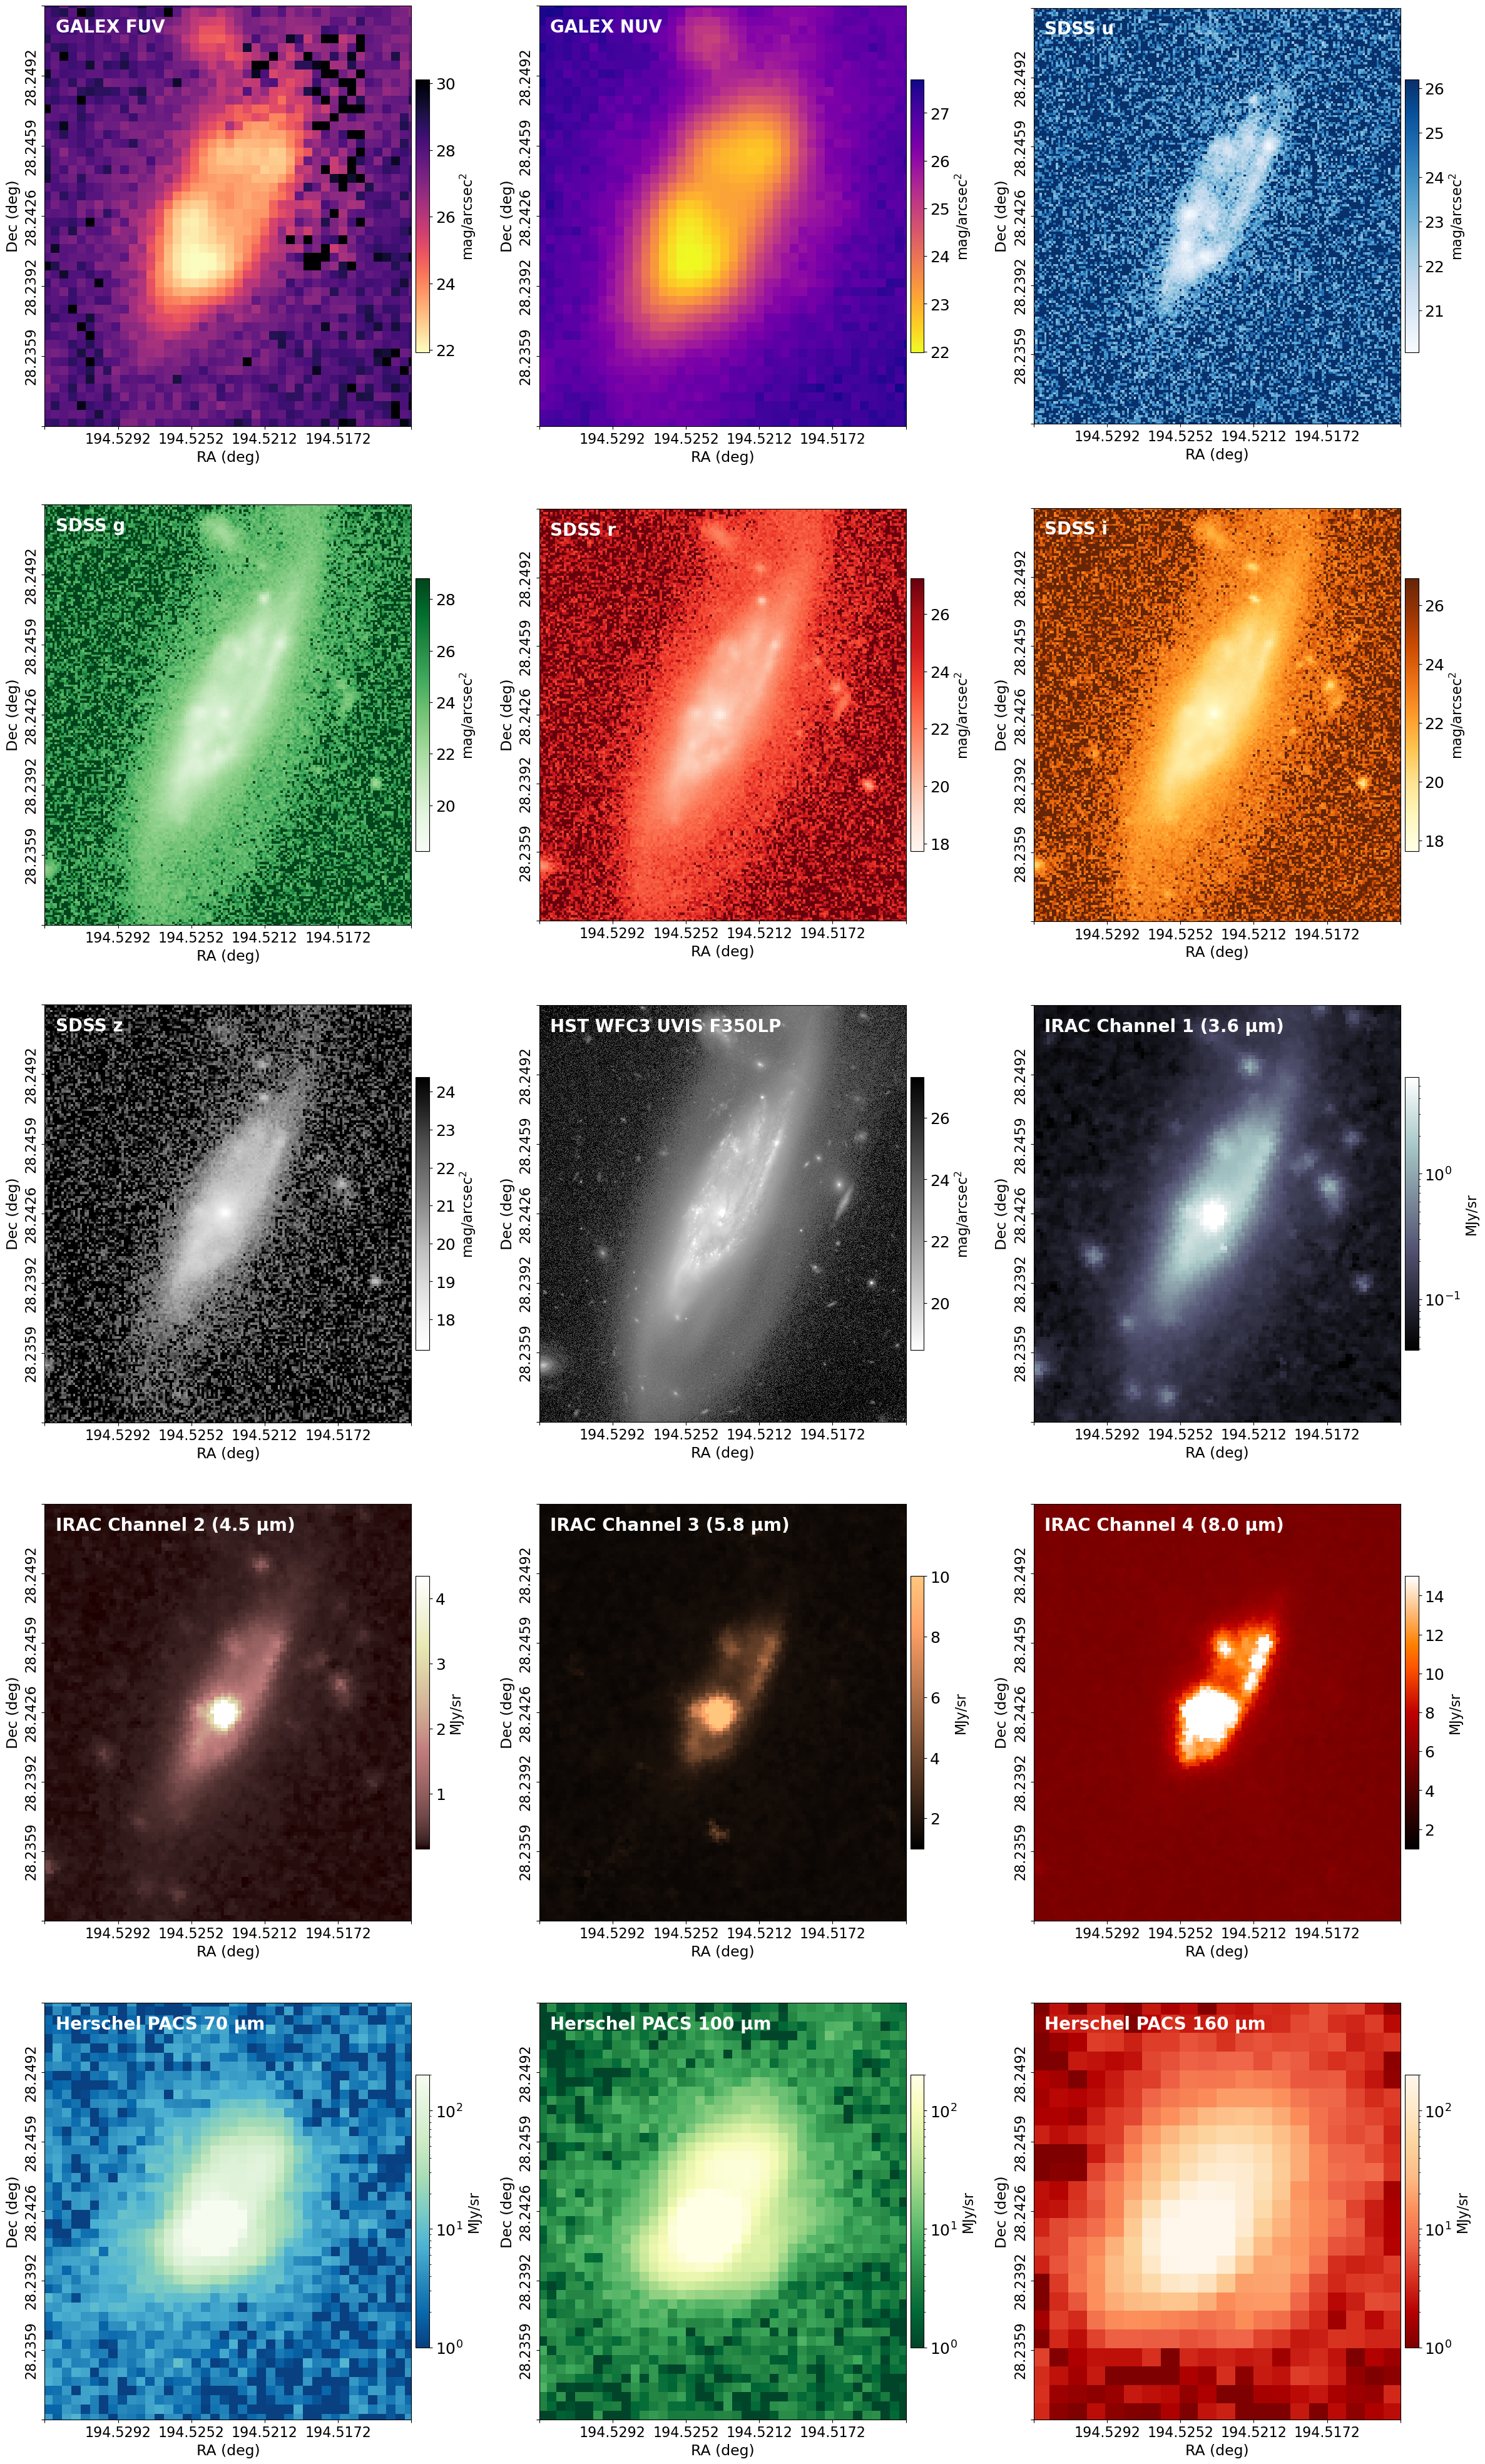

In [6]:
galaxy.plot( 
                
              # bands to plot. Can be just one
              # bands = 'galex_fuv',
              bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','sdss_z','hst_wfc3_uvis_f350lp','spitzer_irac_1',
                     'spitzer_irac_2','spitzer_irac_3','spitzer_irac_4',
                     'herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um'],
              
              plots_per_row=3, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=1,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='white',    # color of autotitle font

              axis_label_fontsize=17,      
              axis_ticks_fontsize=16,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,

              ra_min = ra_center-0.01,
              ra_max = ra_center+0.01,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_cmaps = {'galex_nuv':'plasma',
                           'galex_fuv':'magma',
                           'spitzer_irac_1':'bone',
                           'spitzer_irac_2':'pink',
                           'spitzer_irac_3':'copper',
                           'spitzer_irac_4':'gist_heat',
                           'herschel_pacs_70um':'GnBu_r',
                           'herschel_pacs_100um':'YlGn_r',
                           'herschel_pacs_160um':'OrRd_r',
                          },
              
              set_scale_lims = {
                                'spitzer_irac_3':(1,10),
                                'spitzer_irac_4':(1,15),
                                'herschel_pacs_70um':(1,200),
                                'herschel_pacs_100um':(1,200),
                                'herschel_pacs_160um':(1,200),  
                               },         
            )



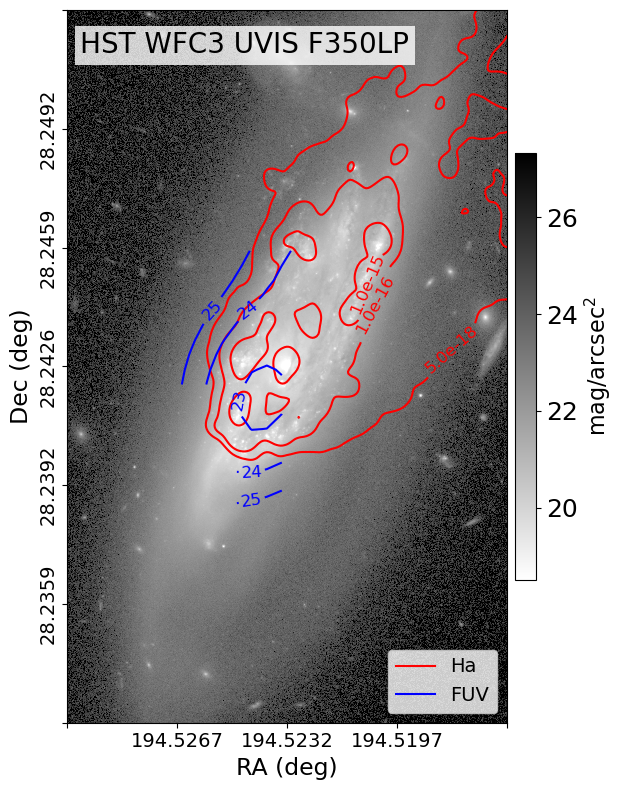

In [57]:
contours = [Contours(image=galaxy.images['muse_Ha'].erg_s_cm2_arcsec2,wcs=galaxy.images['muse_Ha'].wcs,levels=[5e-18,1e-16,1e-15],
                     color='red', linewidth=1.5,clabel_fontsize=12,clabel_fmt='%.1e',label='Ha',),
           Contours(image=galaxy.images['galex_fuv'].mag_arcsec2,wcs=galaxy.images['galex_fuv'].wcs,levels=[23,24,25],
                     color='blue', linewidth=1.5,clabel_fontsize=12,clabel_fmt='%.0f',label='FUV',)] 
galaxy.plot( 
                
              # bands to plot. Can be just one
              bands = ['hst_wfc3_uvis_f350lp'],
              plots_per_row=1, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=0,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='black',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=14,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=3,

              ra_min = ra_center-0.007,
              ra_max = ra_center+0.007,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              contours=contours,

            )

In [8]:
# Define regions to mask stars
circles = []
for ra, dec in [[ra_center,dec_center]]:
    circles.append(
        Region.circle(
            id = ' ',
            ra_center=ra, dec_center=dec, radius=0.001,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='purple'
        )
    )

# Define standard regions as ellipses

ellipses = []
for R in [10, 20, 3.23]:
    angle = 55 if R < 11 else 70
    axis_ratio = 0.4 if R < 11 else 0.36
    ellipses.append(
        Region.ellipse(
            id=f'NGC 4848: R {R} kpc',
            ra_center=ra_center, dec_center=dec_center,
            semimajor_axis=R * theta_deg_1kpc,
            axis_ratio=axis_ratio, angle=angle,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='gainsboro'
        )
    )


In [9]:
muse_obj = galaxy.images['muse_red']
npix_1kpc = theta_deg_1kpc / muse_obj.dtheta_pix_deg         # number of pixels corresponding to 1 kpc

image = muse_obj.erg_s_cm2_A

m_semimajor_ax = np.tan(angle*np.pi/180)
m_sep_line = -1/m_semimajor_ax


# REGIONS FOR MC-SPF
# Define the separator (regions must exclude Ha and Hb)
ra_x_p, dec_x_p = 194.5239703, 28.2387352
x_center, y_center = muse_obj.wcs.all_world2pix([[ra_center,dec_center]],1)[0] 

x_p, y_p = 114, 135 #131
ra_x_p, dec_y_p = muse_obj.wcs.all_pix2world([[x_p, y_p]], 0)[0]

y_coords, x_coords = np.meshgrid(np.linspace(0, image.shape[0], image.shape[0]),np.linspace(0, image.shape[1], image.shape[1]),indexing='ij')
exclude_Ha_mask = (y_coords < m_sep_line * (x_coords - x_p) + y_p)
# REGIONS ARE DEFINED ON MUSE


circular_Region = Region.circle(
            id='1',
            ra_center=ra_center, dec_center=dec_center,
            radius=0.1,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='gainsboro')


regions_for_mcspf = []
from regions import EllipseAnnulusPixelRegion, PixCoord
from astropy import units as u

angle = 55
dr = 1.8
for i,r_kpc in enumerate([5.8,7.6,]):

    region = EllipseAnnulusPixelRegion(
        center=PixCoord(x_center, y_center),
        inner_width = 2 * r_kpc * npix_1kpc, 
        outer_width = 2 * (r_kpc+dr) * npix_1kpc,  
        inner_height = axis_ratio * 2 * r_kpc * npix_1kpc,  
        outer_height = axis_ratio * 2 * (r_kpc+dr) * npix_1kpc,
        angle = angle*u.deg  
    )

    mask_elliptical_annulus = region.to_mask(mode='center').to_image(image.shape).astype(bool)
    #mask_circular_region = circular_Region.to_mask(mode='center').to_image(image.shape).astype(bool)
    mask = np.zeros_like(image, dtype=bool)
    mask |= (mask_elliptical_annulus & exclude_Ha_mask.astype(bool) ) #& ~mask_circular_region)


    if np.any(mask):

        R = r_kpc + dr/2
        print(R)
        x_centroid = x_center - R * npix_1kpc * np.cos(angle*np.pi/180)
        y_centroid = m_semimajor_ax * (x_centroid - x_center) + y_center 
        ra,dec = muse_obj.wcs.all_pix2world([[x_centroid, y_centroid]], 0)[0]

        regions_for_mcspf.append(Region(id=str(i+1),mask=mask,wcs=muse_obj.wcs,caption_coords = [ra,dec],)) 


# Third region

x_p, y_p = 108, 85 #131
angle = 70
ra_x_p, dec_y_p = muse_obj.wcs.all_pix2world([[x_p, y_p]], 0)[0]
m_semimajor_ax = np.tan(angle*np.pi/180)
m_sep_line = -1/m_semimajor_ax
y_coords, x_coords = np.meshgrid(np.linspace(0, image.shape[0], image.shape[0]),np.linspace(0, image.shape[1], image.shape[1]),indexing='ij')
exclude_Ha_mask = (y_coords < m_sep_line * (x_coords - x_p) + y_p)

r_kpc = 10
dr = 5
axis_ratio = 0.34
region = EllipseAnnulusPixelRegion(
    center=PixCoord(x_center, y_center),
    inner_width = 2 * r_kpc * npix_1kpc, 
    outer_width = 2 * (r_kpc+dr) * npix_1kpc,  
    inner_height = axis_ratio * 2 * r_kpc * npix_1kpc,  
    outer_height = axis_ratio * 2 * (r_kpc+dr) * npix_1kpc,
    angle = angle*u.deg  
)

mask_elliptical_annulus = region.to_mask(mode='center').to_image(image.shape).astype(bool)
#mask_circular_region = circular_Region.to_mask(mode='center').to_image(image.shape).astype(bool)
mask = np.zeros_like(image, dtype=bool)
mask |= (mask_elliptical_annulus & exclude_Ha_mask.astype(bool) ) #& ~mask_circular_region)


if np.any(mask):

    R = r_kpc + dr/2
    print(R)
    x_centroid = x_center - R * npix_1kpc * np.cos(angle*np.pi/180)
    y_centroid = m_semimajor_ax * (x_centroid - x_center) + y_center 
    ra,dec = muse_obj.wcs.all_pix2world([[x_centroid, y_centroid]], 0)[0]

    regions_for_mcspf.append(Region(id=str(i+1),mask=mask,wcs=muse_obj.wcs,caption_coords = [ra,dec],)) 



for reg in regions_for_mcspf:
    reg.to_ds9('DATA/Coma/NGC4848/regions',append=True)
    

6.7
8.5
12.5
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg


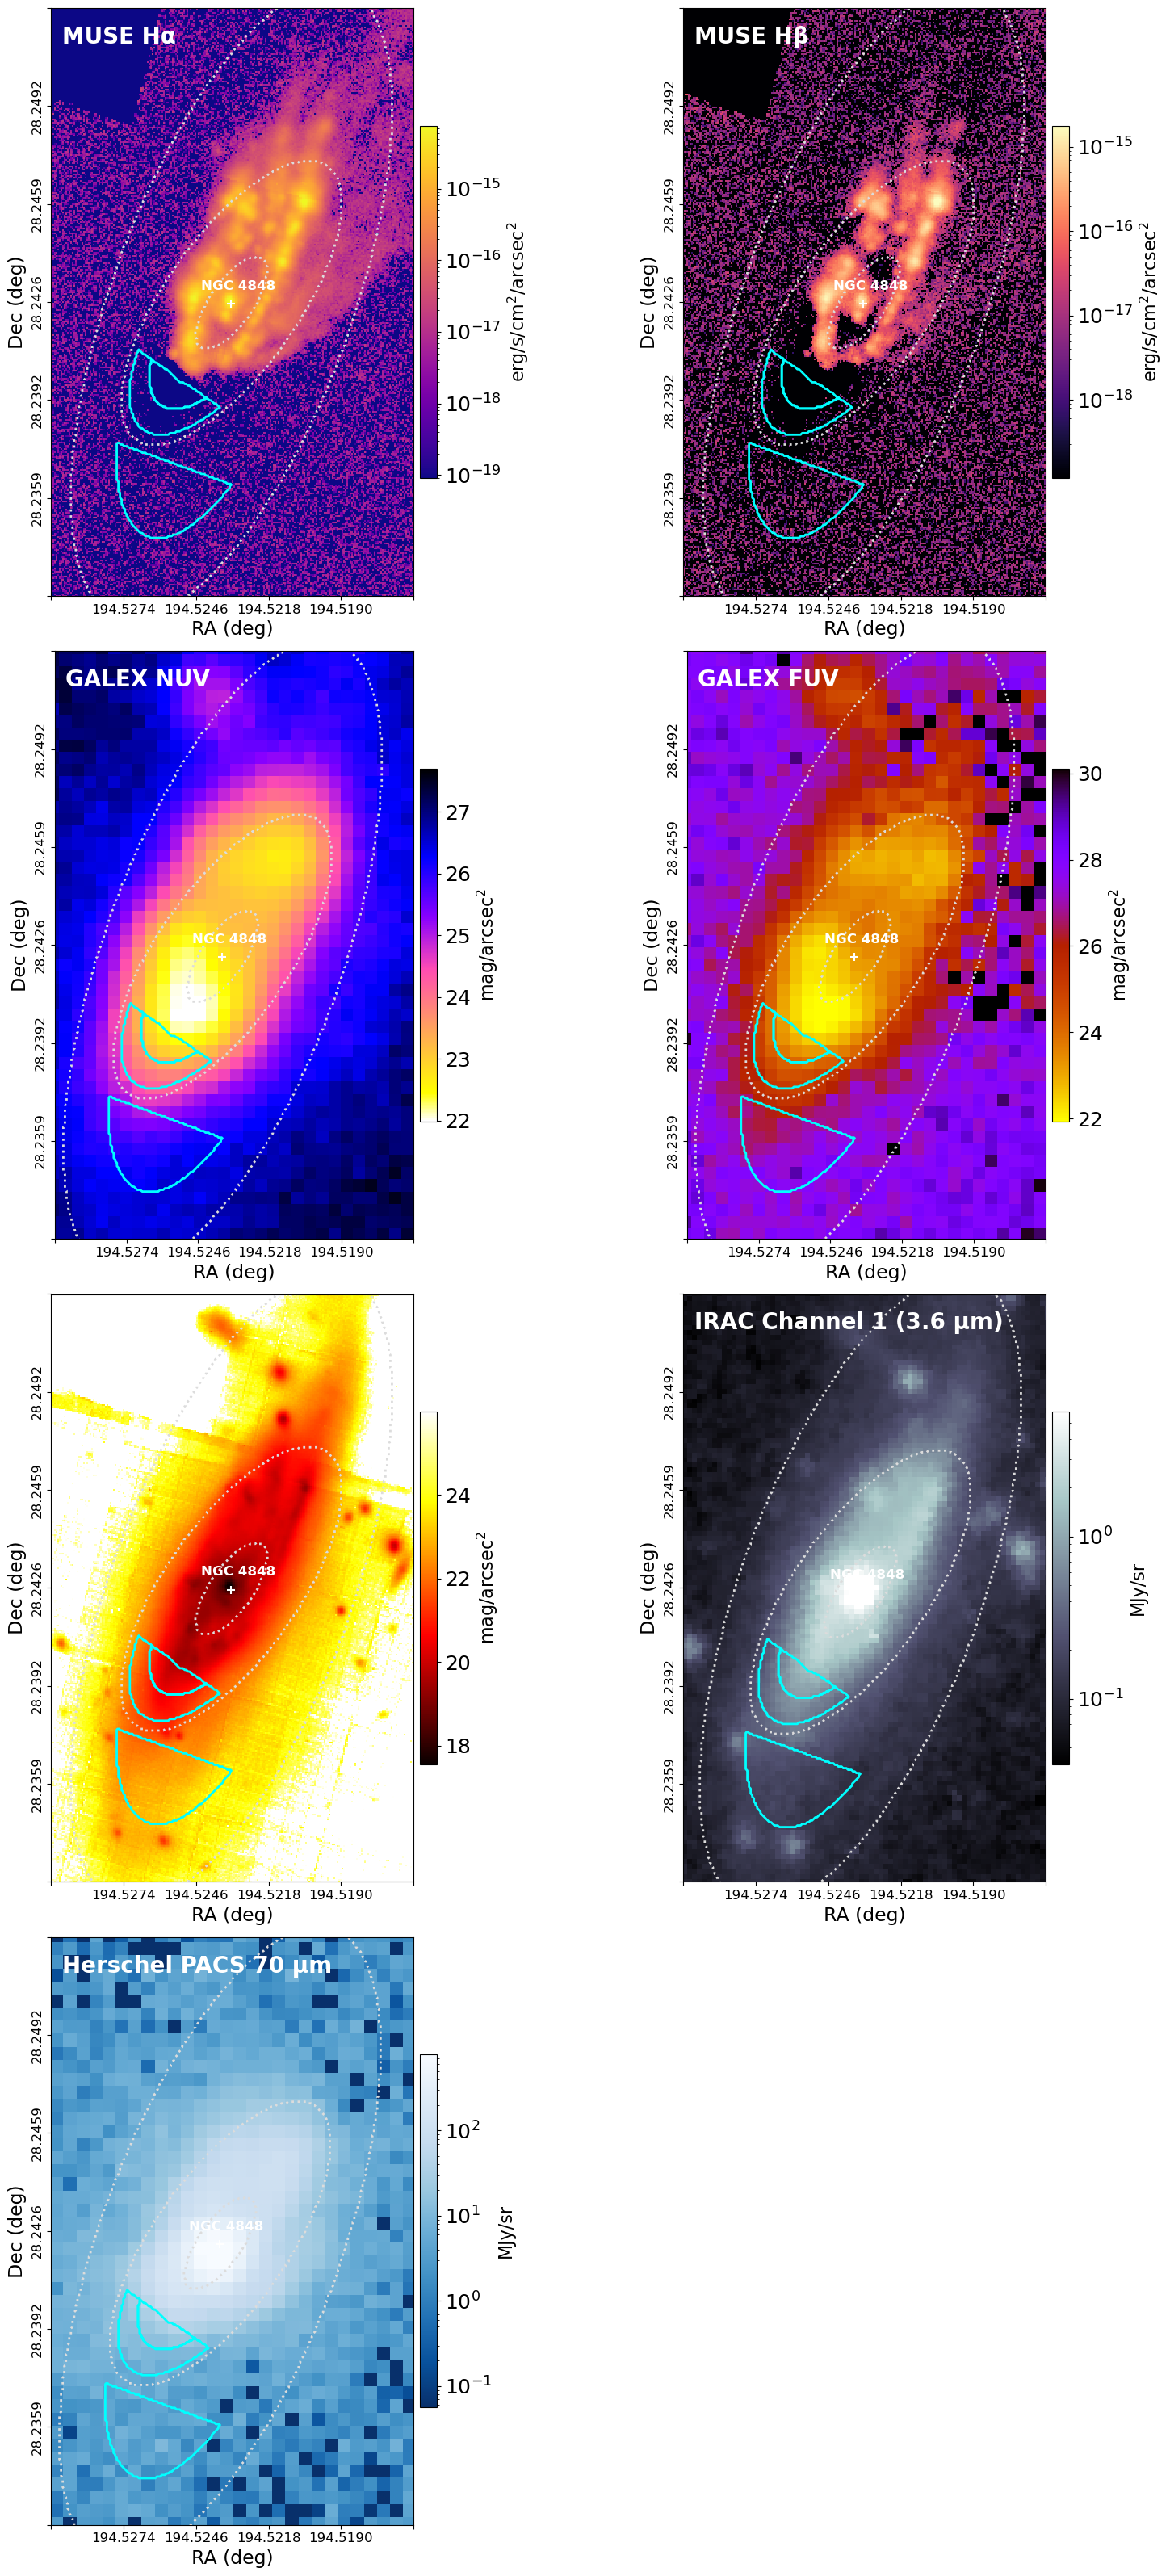

In [10]:
p = Point(coords=(ra_center,dec_center),caption='NGC 4848',caption_fontsize=12,caption_offset=[0.02,0.03],color='white',)

galaxy.plot( 
                
              # bands to plot. Can be just one
              # bands = 'galex_fuv',
              bands=['muse_Ha','muse_Hb','galex_nuv','galex_fuv','muse_red','spitzer_irac_1','herschel_pacs_70um'],
              
              plots_per_row=2, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=1,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='white',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=12,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,

              ra_min = ra_center-0.007,
              ra_max = ra_center+0.007,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_units = {'muse_Ha':'erg_s_cm2_arcsec2','muse_Hb':'erg_s_cm2_arcsec2'},
              set_cmaps = {'muse_Ha':'plasma','muse_Hb':'magma','spitzer_irac_1':'bone','muse_red':'hot_r'},

              regions = regions_for_mcspf+ellipses,
              show_region_captions=False,
              legend=True,
              legend_loc='lower right',
              points = [p],
      
            )

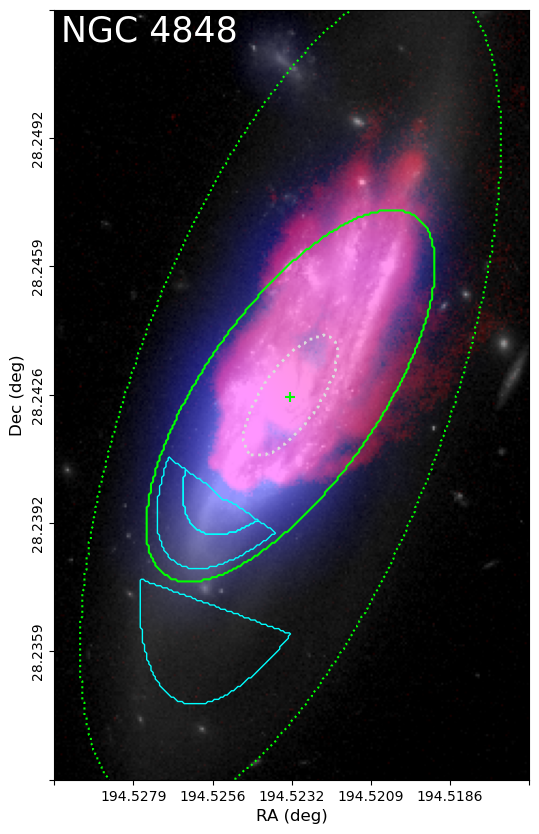

In [131]:
galaxy.make_false_color(
    bands=['muse_Ha','hst_wfc3_uvis_f350lp','galex_nuv'], #'spitzer_irac_1'],
    colors={
        'hst_wfc3_uvis_f350lp': (1,1,1),  # stellar continuum in white
        'muse_Ha':  (1,0,0),              # Hα in red
        'galex_nuv':(0,0,1),              # UV in blue
        'spitzer_irac_1': (0,1,0),
    },
    scale_lims={
        'hst_wfc3_uvis_f350lp': (30,99),  # adjust as needed to show stellar disc
        'muse_Ha':  (70,90),              # tweak to highlight Hα tails
        'galex_nuv':(70,99),             # highlight star-forming regions
        'spitzer_irac_1': (80,95),
    },
    stretch={
        'hst_wfc3_uvis_f350lp': 'log',  # smooth stellar light
        'muse_Ha':'asinh',                  # stretch faint Hα emission
        'galex_nuv':'asinh',                # stretch faint UV
        'spitzer_irac_1': 'asinh',
    },
    gamma=1.3
)

for i in range(3):
    regions_for_mcspf[i].plot_aesthetic(color='cyan',linewidth=1,caption_fontsize=10)
ellipses[0].plot_aesthetic(color='lime',linewidth=1.5,linestyle='-',caption_fontsize=10)
ellipses[1].plot_aesthetic(color='lime',linewidth=1.5,caption_fontsize=10)

p = Point(coords=(ra_center,dec_center),caption='',caption_fontsize=12,caption_offset=[0.02,0.03],color='lime',)

galaxy.plot_false_color(
    rgb_image='rgb',
    ra_min = ra_center-0.007,
    ra_max = ra_center+0.007,
    dec_min = dec_center-0.01,
    dec_max = dec_center+0.01,
    regions=regions_for_mcspf+ellipses,
    title='NGC 4848',
    title_loc=(0.20,0.95),
    title_fontsize=25,
    points=[p],
    show_region_captions=False,
    n
)

# Photometry

In [11]:
bands = ['galex_nuv','galex_fuv',
         'sdss_u', 'sdss_g','sdss_r', 'sdss_i', 'sdss_z',
         'hst_wfc3_uvis_f350lp','hst_wfc3_uvis_f600lp',
         'spitzer_irac_1', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 
         'herschel_pacs_70um', 'herschel_pacs_100um', 'herschel_pacs_160um']

#'wise_w1','wise_w2','wise_w3','wise_w4'
phot_list = []
for i in range(3):
    phot = galaxy.photometry(regions_for_mcspf[i],background_exclude_regions=[ellipses[-1]],print_output=True,bands = bands)
    phot_list.append(phot)


GALEX NUV
Total flux: 0.79598, poisson unc: 0.00337, sky flux: 0.01591, sky std: 0.0023935279574579444
	Flux = 0.02839 ± 0.00134 mJy, SNR = 21.21
GALEX FUV
Total flux: 0.16787, poisson unc: 0.00236, sky flux: 0.00156, sky std: 0.000648141499939062
	Flux = 0.01917 ± 0.00093 mJy, SNR = 20.68
SDSS u
Total flux: 1831.75462, poisson unc: 5.77854, sky flux: 31.70228, sky std: 63.66849211798305
	Flux = 0.09411 ± 0.00482 mJy, SNR = 19.54
SDSS g
Total flux: 21684.94573, poisson unc: 20.03868, sky flux: 38.47004, sky std: 130.38902471496937
	Flux = 0.30624 ± 0.00417 mJy, SNR = 73.46
SDSS r
Total flux: 21580.93979, poisson unc: 19.97903, sky flux: 63.14938, sky std: 154.05617847035748
	Flux = 0.42134 ± 0.00573 mJy, SNR = 73.51
SDSS i
Total flux: 21922.15441, poisson unc: 20.13978, sky flux: 56.71615, sky std: 210.13812833560038
	Flux = 0.53083 ± 0.00722 mJy, SNR = 73.53
SDSS z
Total flux: 5329.86311, poisson unc: 9.88980, sky flux: 57.27141, sky std: 142.04705993281175
	Flux = 0.64810 ± 0.02119 m

In [12]:
for i in range(3):
    phot_list[i].to_fits(f'DATA/Coma/NGC4848/NGC4848_region_{i+1:.0f}.phot')

In [13]:
phot_list[2].print()

,Value,Error,SNR
galex_nuv,0.009813,0.000664,14.780857
galex_fuv,0.003585,0.000421,8.520543
sdss_u,0.036663,0.014040,2.611422
sdss_g,0.140551,0.008610,16.324862
sdss_r,0.247188,0.012682,19.490482
sdss_i,0.331554,0.022882,14.489662
sdss_z,0.435145,0.066818,6.512364
hst_wfc3_uvis_f350lp,0.208152,0.010806,19.262720
hst_wfc3_uvis_f600lp,0.318485,0.016043,19.852453
spitzer_irac_1,0.266188,0.013435,19.813437


In [14]:
spectra = galaxy.cubes.muse.extract_spectra(regions=regions_for_mcspf,pangal_object=galaxy)

In [15]:
spectra[0].header

HIERARCH SOURCE_ID = 'CUBE    '                                                 
HIERARCH REGION_ID = '1       '                                                 
NPIXELS =                  548                                                  
FUNITS  = 'erg/s/cm2/A'                                                         
WUNITS  = 'A       '                                                            
WAVESYS = 'VACUUM  '                                                            

In [16]:
for i,spec in enumerate(spectra):
    spec.header['REDSHIFT'] = z_true
    spec.to_fits(f'DATA/Coma/NGC4848/NGC4848_muse_region_{i+1:.0f}.spec')
    

In [17]:
spectra[0].header

HIERARCH SOURCE_ID = 'CUBE    '                                                 
HIERARCH REGION_ID = '1       '                                                 
NPIXELS =                  548                                                  
FUNITS  = 'erg/s/cm2/A'                                                         
WUNITS  = 'A       '                                                            
WAVESYS = 'VACUUM  '                                                            
REDSHIFT=             0.023974                                                  

In [18]:
phot_list[0].data


 

{'galex_nuv': (0.028387410602288023, 0.001338558546496816),
 'galex_fuv': (0.019169073147807563, 0.0009270254046495331),
 'sdss_u': (0.09411367357124922, 0.004816764121368905),
 'sdss_g': (0.30623675375861914, 0.004168889659262527),
 'sdss_r': (0.4213420270847319, 0.005731913862384779),
 'sdss_i': (0.5308333494484399, 0.0072196928805761075),
 'sdss_z': (0.6480994057561001, 0.021187146404066926),
 'hst_wfc3_uvis_f350lp': (0.43109997645662557, 0.006140937343969813),
 'hst_wfc3_uvis_f600lp': (0.6089247206095323, 0.00867146226566051),
 'spitzer_irac_1': (0.38693172429435624, 0.005508102511651342),
 'spitzer_irac_2': (0.2396899957218369, 0.004789116775961939),
 'spitzer_irac_3': (0.2274078300023752, 0.01671614664658884),
 'spitzer_irac_4': (0.28199988806038606, 0.014896612988512878),
 'herschel_pacs_70um': (4.755206937502995, 0.3821470062628701),
 'herschel_pacs_100um': (11.61853223293199, 0.4454838127255576),
 'herschel_pacs_160um': (3.0466359038841833, 0.07931684194843575)}

In [19]:
nrows = len(regions_for_mcspf)

ID = [i + 1 for i in range(nrows)]
z_best = [z_true for _ in range(nrows)]
dl = [distance for _ in range(nrows)]
polymax = [7 for _ in range(nrows)]
spec_lim = ['4000,6800' for _ in range(nrows)]
res_file = ['Extracted_resolution.fits' for _ in range(nrows)]

columns = []
columns.append(fits.Column(name='id', format='K', array=np.array(ID, dtype='int64')))
columns.append(fits.Column(name='z_best', format='D', array=np.array(z_best)))
columns.append(fits.Column(name='dl', format='D', array=np.array(dl)))
columns.append(fits.Column(name='polymax', format='J', array=np.array(polymax, dtype='int32')))
columns.append(fits.Column(name='spec_file', format='93A', array=[''] * nrows))  # Optional if not used
columns.append(fits.Column(name='spec_lim', format='9A', array=np.array(spec_lim)))
columns.append(fits.Column(name='res_file', format='72A', array=np.array(res_file)))

for band in phot_list[0].data.keys():
    columns.append(fits.Column(name='f_' + band, format='D', array=np.zeros(nrows)))
    columns.append(fits.Column(name='e_' + band, format='D', array=np.zeros(nrows)))

# Create the HDU
coldefs = fits.ColDefs(columns)
hdu = fits.BinTableHDU.from_columns(coldefs)

# Fill in photometry
for i in range(nrows):
    for band in phot_list[i].data.keys():
        hdu.data[i]['f_' + band] = phot_list[i].data[band][0]
        hdu.data[i]['e_' + band] = phot_list[i].data[band][1]

spec_filepath = 'DATA/Coma/NGC4848/test_mcspf'
for i,spec in enumerate(spectra):
    w = spec.wl
    flux = spec.flux
    err = spec.flux_err

    # Create the fits file:
    primary_hdu = fits.PrimaryHDU(flux/1e-20)
    hdu_error = fits.ImageHDU(err/1e-20)
    hdu_wavelength = fits.ImageHDU(w)
    # Combine into HDUList
    hdul = fits.HDUList([primary_hdu, hdu_error, hdu_wavelength])

    # Write to file
    output_file = 'DATA/Coma/NGC4848/test_mcspf/muse_spec_'+str(i)+'.fits'
    hdul.writeto(output_file, overwrite=True)

    hdu.data[i]['spec_file'] = 'muse_spec_'+str(i)+'.fits'


print(hdu.data[1])


# Assume your BinTableHDU is called `bintable_hdu`
primary_hdu = fits.PrimaryHDU()  # Empty primary header
hdul = fits.HDUList([primary_hdu, hdu])

hdul.writeto('DATA/Coma/NGC4848/test_mcspf/phot_file.fits', overwrite=True)

(2, 0.023974, 104.0, 7, 'muse_spec_1.fits', '4000,6800', 'Extracted_resolution.fits', 0.026752736067577942, 0.001261478336546264, 0.013137285121630248, 0.0006599010129157558, 0.07126034494870655, 0.00767681510786215, 0.24693010781852046, 0.004866412700866522, 0.39220560627380197, 0.006433313176982335, 0.49744545728431927, 0.01097172758563512, 0.6059350114201092, 0.03012891433088846, 0.3472356155159439, 0.0061567099346345085, 0.5155553889522457, 0.008176359827900997, 0.38139792529166444, 0.006891693571949092, 0.2403872236749445, 0.007448862611491486, 0.2687591529091831, 0.0266934157146716, 0.32105357153883196, 0.025193049630022904, 5.0099284363048575, 0.6496183022545085, 9.362675772104739, 0.92595455809443, 7.275325945594757, 0.294279561194438)


# FITTING THE MODEL

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob

import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

#from pangal.pfitter import PFitter
from pangal.photometry_table import PhotometryTable

from pangal.pfitter import PFitter
#from pangal.fit_diagnostic import fit_diagnostic
from pangal.run import Run
from pangal.spectrum import Spectrum
#from build_boissier import load_spectrum_models_from_fits

import warnings
warnings.simplefilter("ignore")

In [2]:
phot = []
for i in range(3):
    phot.append(PhotometryTable().from_fits(f'DATA/Coma/NGC4848/NGC4848_region_{i+1:.0f}.phot'))



In [3]:
phot[0].print()

,Value,Error,SNR
galex_nuv,0.028387,0.001339,21.207448
galex_fuv,0.019169,0.000927,20.678045
sdss_u,0.094114,0.004817,19.538776
sdss_g,0.306237,0.004169,73.457630
sdss_r,0.421342,0.005732,73.508088
sdss_i,0.530833,0.007220,73.525752
sdss_z,0.648099,0.021187,30.589273
hst_wfc3_uvis_f350lp,0.431100,0.006141,70.201006
hst_wfc3_uvis_f600lp,0.608925,0.008671,70.221688
spitzer_irac_1,0.386932,0.005508,70.247735


In [4]:
from pangal.spectrum import Spectrum
spectra = []
for i in range(3):
    spectra.append(Spectrum().from_fits(f'DATA/Coma/NGC4848/NGC4848_muse_region_{i+1:.0f}.spec'))

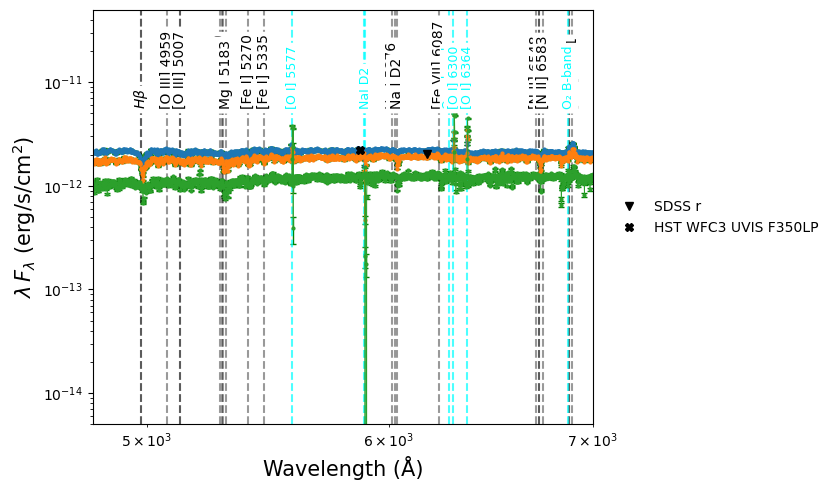

In [5]:
Spectrum().plot(figsize=(10,5),spectra=spectra, per_wavelength=True, phot=phot[0], #show_phot_legend=True,
              winf=4800,wsup=7000, 
                #ymin=5e-13, ymax= 1.5e-11, 
                #y_units='mJy',
                show_all_spectral_lines=True,show_top_spectral_lines=True,
                show_atmospheric_lines=True,show_spec_legend=False)


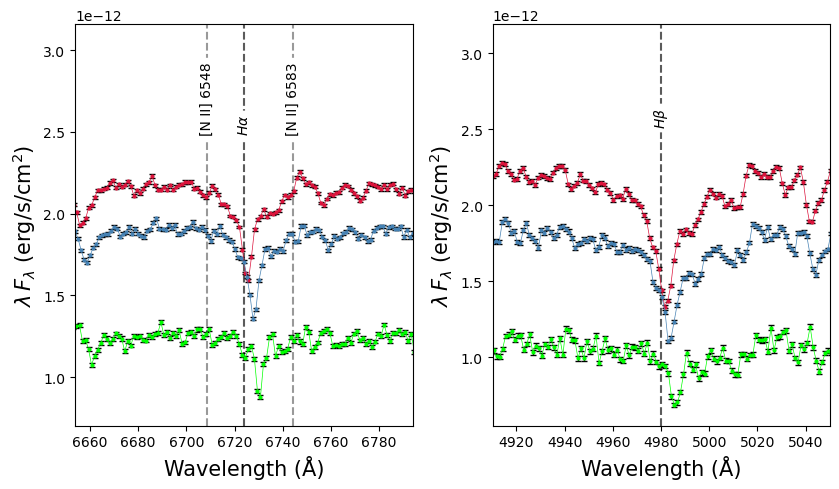

In [9]:
Spectrum().plot(figsize=(10,5),
                spectra=spectra, 
                per_wavelength=True, 
                phot=phot[0], #show_phot_legend=True,
                winf=4800,wsup=7000, 
                zoom_on_line=['Ha','Hb'],
                redshift = 0.0245, 
                #ymin=5e-13, ymax= 1.5e-11, 
                #y_units='mJy',
                color=['crimson','steelblue','lime'],
                ecolor='k',
                show_all_spectral_lines=True,show_top_spectral_lines=True,
                show_atmospheric_lines=True,show_spec_legend=False) 


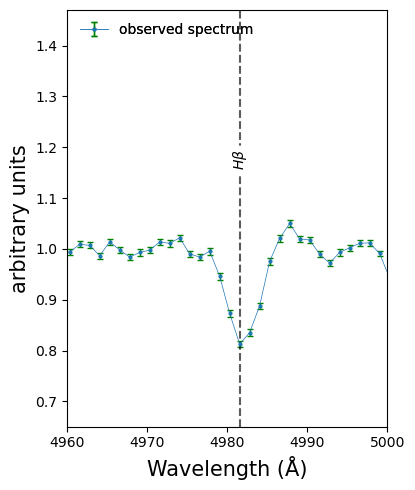

In [10]:
Spectrum().plot(figsize=(5,5),
                spectra=[spectra[0]], 
                per_wavelength=True, 
                remove_continuum=True,
                winf=4960,wsup=5000, 
                #zoom_on_line=['Ha','Hb'],
                redshift = 0.0248, 
                #ymin=5e-13, ymax= 1.5e-11, 
                #y_units='mJy',
                show_all_spectral_lines=True,show_top_spectral_lines=True,
                show_atmospheric_lines=True,show_spec_legend=True) 


In [8]:
spectra[0].get_phot(bands=['sdss_r'],method='quad',units='mJy')

PhotometryTable(data={'sdss_r': (0.45343935710888983, nan)}, header=UNITS   = 'mJy     '                                                            )

In [9]:
spectra[0].get_phot(bands=['sdss_r'],method='trapz',units='mJy')

PhotometryTable(data={'sdss_r': (0.44639553487404243, nan)}, header=UNITS   = 'mJy     '                                                            )

In [5]:

fitter_7kpc = PFitter(model_file='new_models/V_160_R_7.fits',
             model_pars=['TRUNCAGE','TRUNCTAU',], 
             uv_bump = False,
             leitatt = False,
            )


fitter_10kpc = PFitter(model_file='new_models/V_160_R_10.fits',
             model_pars=['TRUNCAGE','TRUNCTAU',], 
             uv_bump = False,
             leitatt = False,
            )



Initializing PFitter object
Loading models from  new_models/V_160_R_7.fits
 Pre-computed model grid:
   - TRUNCAGE: 31 values, min=4.0, max=3000.0
   - TRUNCTAU: 28 values, min=2.0, max=2000.0
Dust attenuation curve from Calzetti 2000.
Loading nebular lines templates from nebular_Byler_mist_2018.lines
Emission line metallicity requested 0.017, found 0.0200
Tabulated gas ages (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated ionization grid: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3.125
 3.1875 3.25   3.3125 3.375  3.4375 3.5    3.5625 3.625  3.6875 3

# We will start by fitting only photometry


In [18]:
"""
custom_prior = {
    'av':     {'type':'uniform', 'low':0.0,    'high':0.2},
    'av_ext':     {'type':'uniform', 'low':0.0,    'high':0.2},
    'm_star':  {'type':'uniform', 'low':8.2,    'high':9.4},   
}

bands = ['galex_nuv','galex_fuv','sdss_u', 'sdss_g','sdss_r', 'sdss_i', 'sdss_z',
         'hst_wfc3_uvis_f350lp','hst_wfc3_uvis_f600lp',
         'spitzer_irac_1', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 
         'herschel_pacs_70um', 'herschel_pacs_160um', 'herschel_pacs_100um']




res_phot_1 = fitter_7kpc.run_fit(phot=phot[0], 
                     fix_pars={'redshift':0.023974,'luminosity_distance':104,'fesc':0,'age_gas':11,'ion_gas':-1},
                     treat_as_upper_limits=['herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um',],
                     nlive=100,
                     dlogz=0.1,
                     custom_priors=custom_prior,
                     )


custom_prior = {
    'av':     {'type':'uniform', 'low':0.0,    'high':0.2},
    #'alpha':  {'type':'uniform', 'low':1.5,    'high':3},
    'm_star':  {'type':'uniform', 'low':8.0,    'high':9.5},
    #'sigma_vel': {'type':'uniform', 'low':0,    'high':400},
    #'vel_sys': {'type':'uniform', 'low':-500,    'high':+500},
    #'TRUNCTAU': {'type':'uniform', 'low':50,    'high':500},
    'fesc': {'type':'uniform', 'low':-0.01,    'high':0.01},
    
}

res_spec_1 = fitter_7kpc.run_fit(phot=phot[0], 
                                 spec=spectra[0],
                                 spectral_range=[4800,7000],
                                 treat_as_upper_limits=['herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um'],
                     fix_pars={'redshift':0.023974,'luminosity_distance':104,'ion_gas':-3.94,'age_gas':13,'f_esc':1,},
                     nlive=500,
                     dlogz=0.01,
                     custom_priors=custom_prior,
                     )

res_phot_1.save('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITPHOT_noemission_pacs_upplim.npz')
                     
"""

Using the following photometric filters: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, hst_wfc3_uvis_f350lp, hst_wfc3_uvis_f600lp, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um
Setting as upper limits: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, hst_wfc3_uvis_f350lp, hst_wfc3_uvis_f600lp, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um
No spectral data. Neglecting kinematics
Fixed parameter: redshift = 0.023974
Fixed parameter: luminosity_distance = 104
Fixed parameter: fesc = 0
Fixed parameter: age_gas = 11
Fixed parameter: ion_gas = -1
Fixed parameter: vel_sys = 0
Fixed parameter: sigma_vel = 0
Fixed parameter: sigma_gas = 0
Fixed parameter: spec_noise_scale = 0
Fitting:  TRUNCAGE
Fitting:  TRUNCTAU
Fitting:  av
Fitting:  av_ext
Fitting:  alpha
Fitting:  m_star

Priors:
  - TRUNCAGE: Uniform(4.0, 

2219it [00:58, 37.90it/s, +100 | bound: 149 | nc: 1 | ncall: 26168 | eff(%):  8.896 | loglstar:   -inf < -63.747 <    inf | logz: -83.520 +/-    nan | dlogz:  0.001 >  0.100]


In [6]:
res_phot_1 = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITPHOT_noemission.npz')
res_phot_2 = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITPHOT_noemission.npz')
res_phot_3 = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITPHOT_noemission.npz')

res_phot_1_pacs_upp_lim = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITPHOT_noemission_pacs_upplim.npz')
res_phot_2_pacs_upp_lim = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITPHOT_noemission_pacs_upplim.npz')
res_phot_3_pacs_upp_lim = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITPHOT_noemission_pacs_upplim.npz')

res_spec_1_pacs_upp_lim = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim.npz')
res_spec_2_pacs_upp_lim = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim.npz')
res_spec_3_pacs_upp_lim = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim.npz')

res_spec_1_pacs_upp_lim_noemm = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim_FESC_1.npz')
res_spec_2_pacs_upp_lim_noemm = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim_FESC_1.npz')
res_spec_3_pacs_upp_lim_noemm = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim_FESC_1.npz')

Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITPHOT_noemission.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITPHOT_noemission.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITPHOT_noemission.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim_FESC_1.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim

[4800 7000]
Spectrum(wl=array([4800.24116043, 4801.49149178, 4802.74182314, ..., 6997.07886623,
       6998.3292028 , 6999.57953937], dtype='>f8'), resolution=array([1662.68841224, 1663.31989408, 1663.95142891, ..., 2770.72515113,
       2771.30747258, 2771.88968498], dtype='>f8'), flux=array([4.46022510e-16, 4.52463401e-16, 4.43551609e-16, ...,
       2.96640600e-16, 3.01227309e-16, 2.95387891e-16], dtype='>f8'), flux_err=array([2.80431971e-18, 2.83368896e-18, 2.83980700e-18, ...,
       1.24873998e-18, 1.28723334e-18, 1.27375309e-18], dtype='>f8'), header=WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         )
PhotometryTable(data={'galex_nuv': (0.028387410602288023, 0.001338558546496816), 'galex_fuv': (0.019169073147807563, 0.0009270254046495331), 'sdss_u': (0.09411367357124922, 0.004816764121368905), 'sdss_g': (0.30623675375861914, 0.004168889659262527), 'sdss_r': (0.421342027

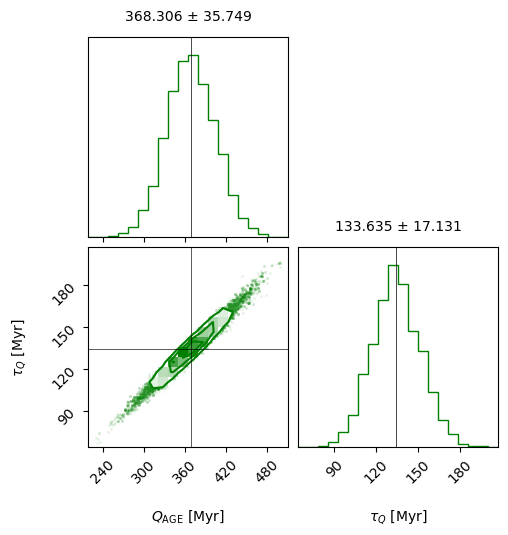

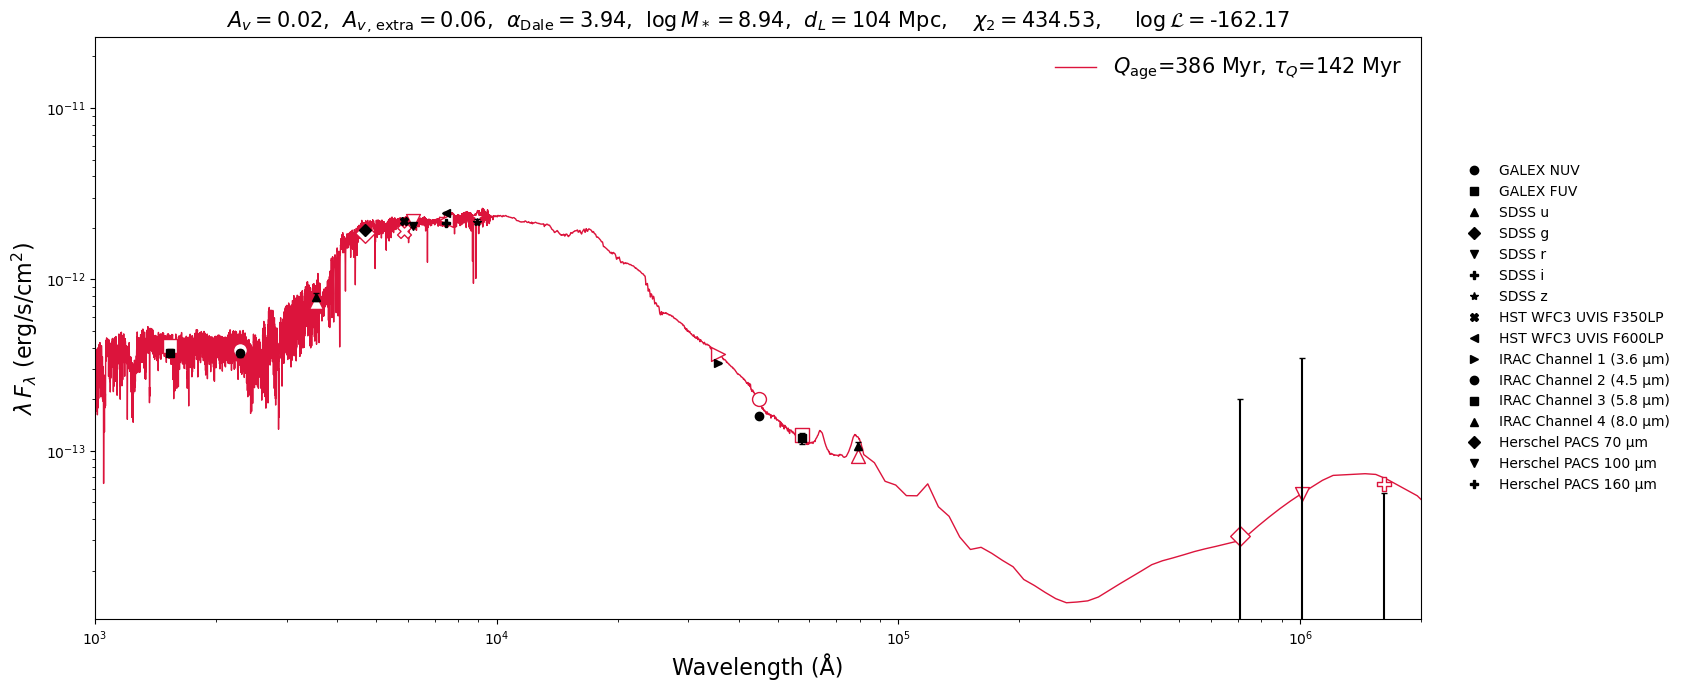

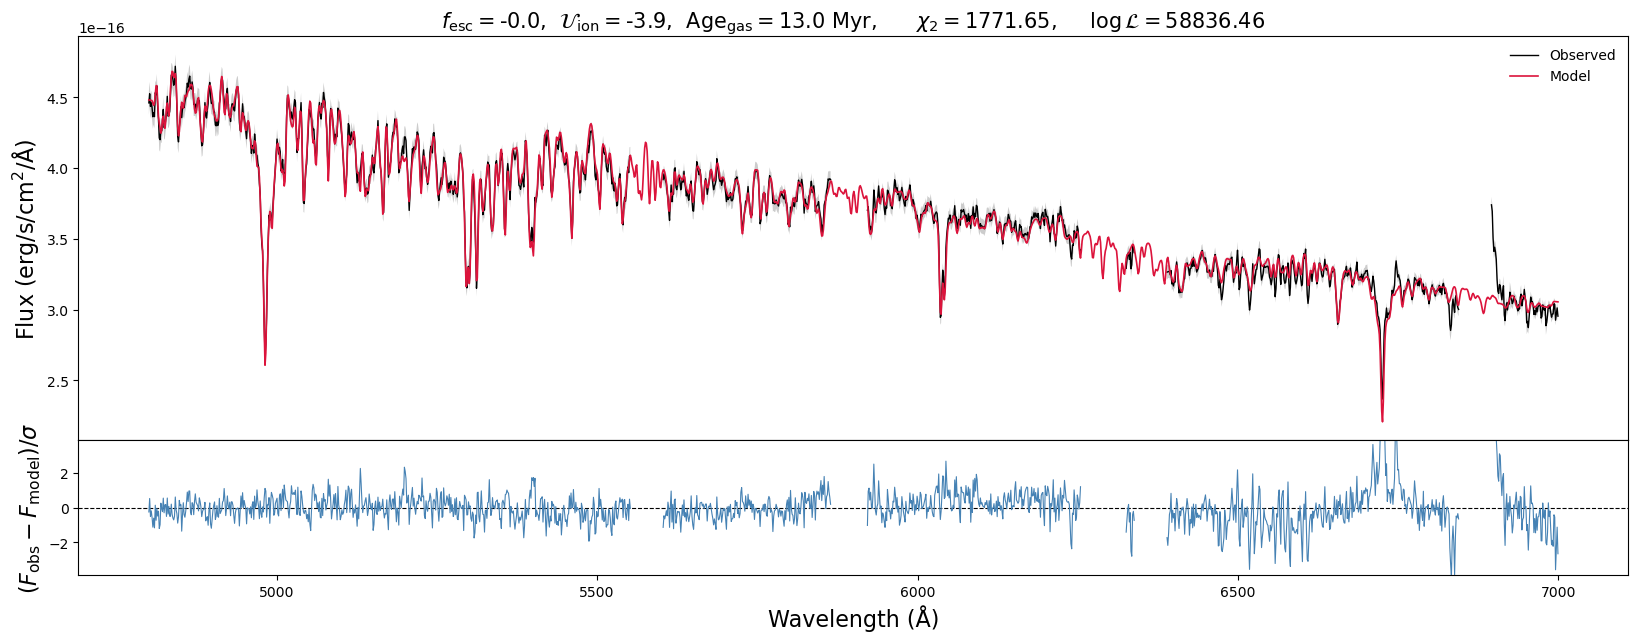

In [17]:
res = res_spec_1_pacs_upp_lim_noemm
fitter = fitter_7kpc

print(res.spectral_range)
print(res.spec_crop)
print(res.phot)
print(res.model_file)
print(res.model_pars)
print(res.free_pars)
print(res.fix_pars)
print(res.custom_priors)
print(res.polydeg)
print(res.bands)
print(res.treat_as_upper_limits)
print(res.best_model())

res.cornerplot(parameters=['TRUNCAGE','TRUNCTAU'],
               #cmap='Greens',
               show_stats=True, 
               show_histograms=True,          
               #contour_color='k',
               mark_point="median",
               mark_color='black',
               contour_color='green',
               mark_lw=0.5
              )



params = res.best_model()

spec_legend_pars = {
    'TRUNCAGE': dict(label="$Q_\\text{age}$", unit="Myr", fmt=".0f"),
    'TRUNCTAU': dict(label="$\\tau_Q$", unit="Myr", fmt=".0f"),
    #'av':    dict(label="$A_V$", unit="", fmt=".2f"),
}

fitter.fit_diagnostic(
        params=params,
        spec=spectra[0],
        spectral_range=[4800,7000],
        polydeg=5,
        phot=phot[0],
        color='crimson',
        treat_as_upper_limits=['herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um'],
        #winf_spec=4800,wsup_spec=5200,
        winf_phot=1e3,wsup_phot=2e6,
        spec_legend_pars=spec_legend_pars,
        spec_legend_fontsize=15,
        title_fontsize=15,
        title_color='black',
        label_fontsize=16,
    )


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import corner
from dynesty.utils import resample_equal


# ------------------------------------------------------------
# Helper: equal-weight samples
# ------------------------------------------------------------
def get_equal_samples(fitter, indices):
    samples = fitter.result.samples
    weights = np.exp(fitter.result.logwt - fitter.result.logz[-1])
    eq = resample_equal(samples, weights)
    return eq[:, indices]


# ------------------------------------------------------------
# Helper: overlay bubbles on existing corner figure
# ------------------------------------------------------------
def overlay_bubbles_on_corner(fig, samples_2d, color="C0", s=8, alpha=0.4):

    n = samples_2d.shape[1]

    # corner axis indexing
    for i in range(n):
        for j in range(i):
            ax = fig.axes[i * n + j]

            ax.scatter(
                samples_2d[:, j],
                samples_2d[:, i],
                s=s,
                alpha=alpha,
                color=color,
                edgecolors="none",
                zorder=20,
            )


# ------------------------------------------------------------
# MAIN FUNCTION
# ------------------------------------------------------------
from matplotlib.lines import Line2D
def multi_cornerplot(
    fitters,
    parameters,
    labels=None,
    colors=None,
    legend_labels=None,   # <-- NEW
    show_histograms=True,
    max_points=None
):

    # Default colors
    if colors is None:
        colors = ["C0", "C1", "C2", "C3", "C4"]

    # Parameter indices
    free_pars = fitters[0].free_pars
    indices = [free_pars.index(p) for p in parameters]

    if labels is None:
        labels = parameters

    # ------------------------------------------------------------
    # Compute global parameter ranges
    # ------------------------------------------------------------
    all_samples = []
    
    for fitter in fitters:
        eq = get_equal_samples(fitter, indices)
        all_samples.append(eq)
    
    all_samples = np.vstack(all_samples)
    
    ranges = [
        (np.min(all_samples[:, i]), np.max(all_samples[:, i]))
        for i in range(all_samples.shape[1])
    ]
    
        
    # ------------------------------------------------------------
    # BASE CORNER
    # ------------------------------------------------------------
    base_samples = get_equal_samples(fitters[0], indices)

    fig = plt.figure(figsize=(8, 8))   # adjust size here
    
    corner.corner(
        base_samples,
        labels=labels,
        range=ranges,   # ← IMPORTANT
        plot_contours=False,
        plot_density=False,
        fill_contours=False,
        plot_datapoints=False,
        color=colors[0],
        fig=fig,
    )

    # ------------------------------------------------------------
    # Overlay bubbles
    # ------------------------------------------------------------
    for k, fitter in enumerate(fitters):

        eq = get_equal_samples(fitter, indices)

        if max_points and len(eq) > max_points:
            rng = np.random.default_rng(0)
            eq = eq[rng.choice(len(eq), max_points, replace=False)]

        overlay_bubbles_on_corner(
            fig,
            eq,
            color=colors[k],
            s=10,
            alpha=0.35
        )

    # ------------------------------------------------------------
    # Hide diagonals
    # ------------------------------------------------------------
    diag_axes = [fig.axes[i * (len(parameters) + 1)] for i in range(len(parameters))]
    for ax in diag_axes:
        ax.set_visible(False)

    # ------------------------------------------------------------
    # Add legend INSIDE cornerplot
    # ------------------------------------------------------------
    if legend_labels is not None:

        handles = [
            Line2D([0], [0], marker="o", linestyle="",
                   color=colors[i], label=legend_labels[i], markersize=6)
            for i in range(len(legend_labels))
        ]

        n = len(parameters)
        legend_ax = fig.axes[n * (n - 1)]   # bottom-left panel
        legend_ax.legend(handles=handles, loc="upper left", frameon=False)

    return fig



from matplotlib.lines import Line2D

def multi_corner_contours(
    fitters,
    parameters,
    labels=None,
    ranges=None,
    colors=("C0", "C1", "C2"),
    legend_labels=None,   # <-- NEW
    linewidths=2.0,
    smooth=1.0,
    hide_diagonal=True,
    show_histograms=False,
    bins=30,
):
    free_pars = fitters[0].free_pars
    indices = [free_pars.index(p) for p in parameters]
    n = len(parameters)

    if labels is None:
        labels = parameters

    fig = plt.figure(figsize=(8, 8))

    # ------------------------------------------------------------
    # Draw contours
    # ------------------------------------------------------------
    for k, fitter in enumerate(fitters):
        eq = get_equal_samples(fitter, indices)

        corner.corner(
            eq,
            fig=fig,
            labels=labels if k == 0 else None,
            bins=bins,
            smooth=smooth,
            range=ranges,   # ← IMPORTANT

            plot_datapoints=False,
            plot_density=False,
            plot_contours=True,
            fill_contours=False,

            contour_kwargs={
                "colors": colors[k % len(colors)],
                "linewidths": linewidths,
            },

            hist_kwargs={"histtype": "step", "linewidth": 0.0} if not show_histograms else None,
            color=colors[k % len(colors)],
        )

    # ------------------------------------------------------------
    # Hide diagonal panels
    # ------------------------------------------------------------
    if hide_diagonal:
        diag_axes = [fig.axes[i * (n + 1)] for i in range(n)]
        for ax in diag_axes:
            ax.set_visible(False)

    # ------------------------------------------------------------
    # Add legend
    # ------------------------------------------------------------
    if legend_labels is not None:

        handles = [
            Line2D([0], [0],
                   color=colors[i],
                   lw=linewidths,
                   label=legend_labels[i])
            for i in range(len(legend_labels))
        ]

        # Place legend on guaranteed visible panel
        legend_ax = fig.axes[n * (n - 1)]
        legend_ax.legend(handles=handles, loc="upper left", frameon=False)

    return fig

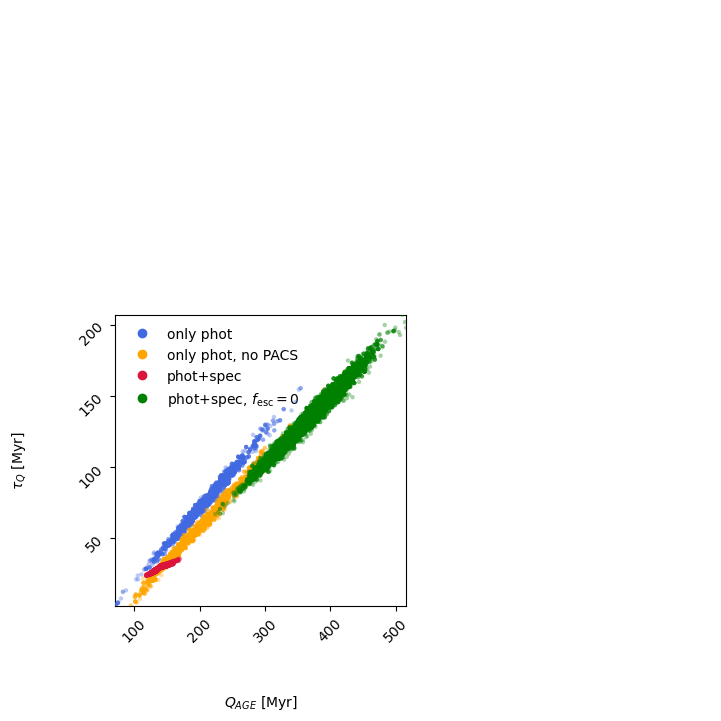

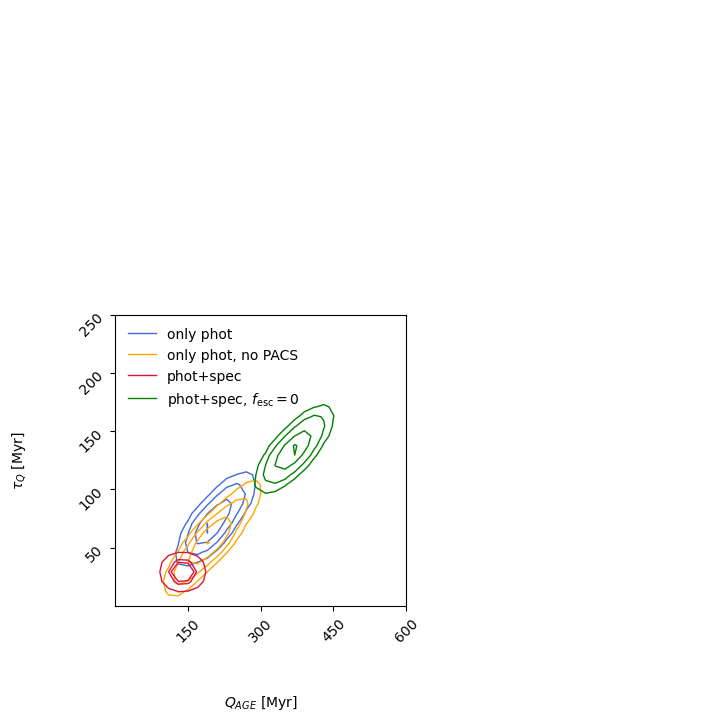

In [30]:
fig = multi_cornerplot(
    fitters=[res_phot_1, res_phot_1_pacs_upp_lim, res_spec_1_pacs_upp_lim, res_spec_1_pacs_upp_lim_noemm],
    parameters=["TRUNCAGE", "TRUNCTAU"],
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"],
    legend_labels=["only phot", "only phot, no PACS", "phot+spec", "phot+spec, $f_\\text{esc}=0$"],
    colors=["royalblue", "orange", "crimson", "green"]
)

plt.show()

fig = multi_corner_contours(
    fitters=[res_phot_1, res_phot_1_pacs_upp_lim, res_spec_1_pacs_upp_lim, res_spec_1_pacs_upp_lim_noemm],
    parameters=["TRUNCAGE", "TRUNCTAU"], 
    ranges = [(0,600),(0,250)], 
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"],
    legend_labels=["only phot", "only phot, no PACS", "phot+spec", "phot+spec, $f_\\text{esc}=0$"],
    colors=["royalblue", "orange", "crimson", "green"],
    linewidths=1,
)

plt.show()

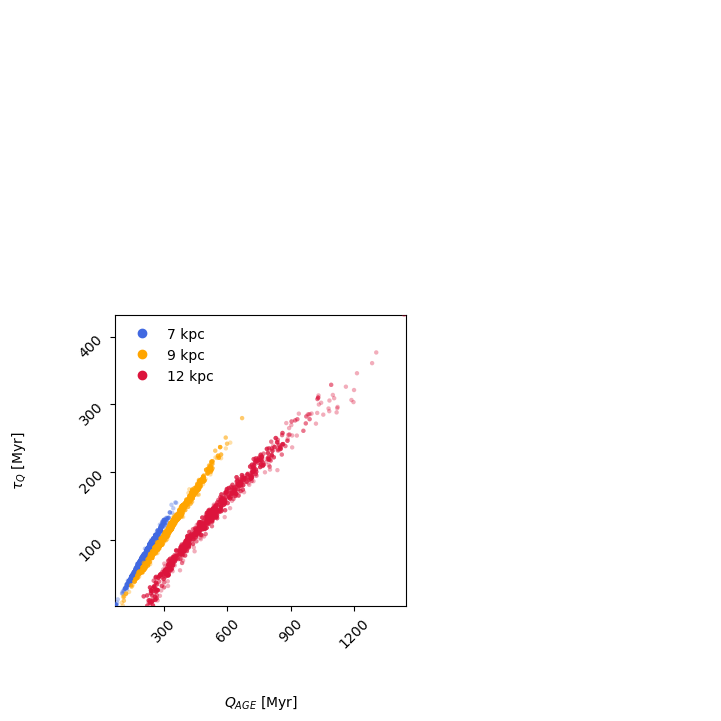

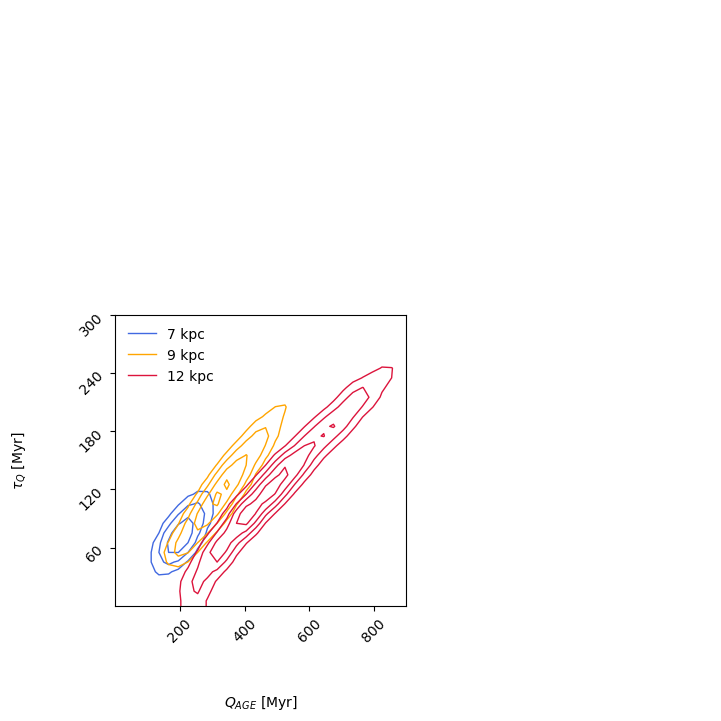

In [22]:
fig = multi_cornerplot(
    fitters=[res_phot_1, res_phot_2, res_phot_3],
    parameters=["TRUNCAGE", "TRUNCTAU"],
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"],
    legend_labels=["7 kpc", "9 kpc", "12 kpc"],
    colors=["royalblue", "orange", "crimson"]
)

plt.show()

fig = multi_corner_contours(
    fitters=[res_phot_1, res_phot_2, res_phot_3],
    parameters=["TRUNCAGE", "TRUNCTAU"], # ,"av"],
    ranges = [(0,900),(0,300)], #(0,0.2)],
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"], # "$A_V$"],
    legend_labels=["7 kpc", "9 kpc", "12 kpc"],
    colors=["royalblue", "orange", "crimson"],
    linewidths=1,
)

plt.show()

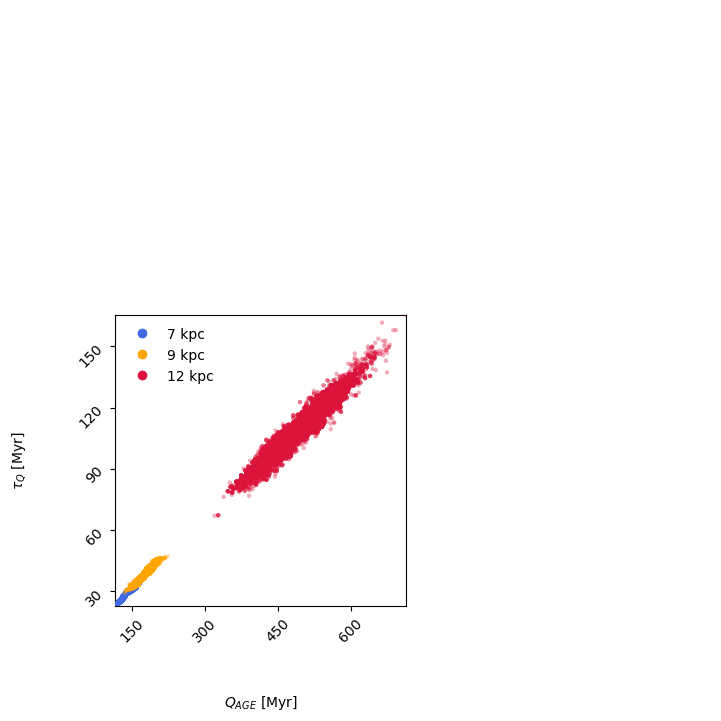

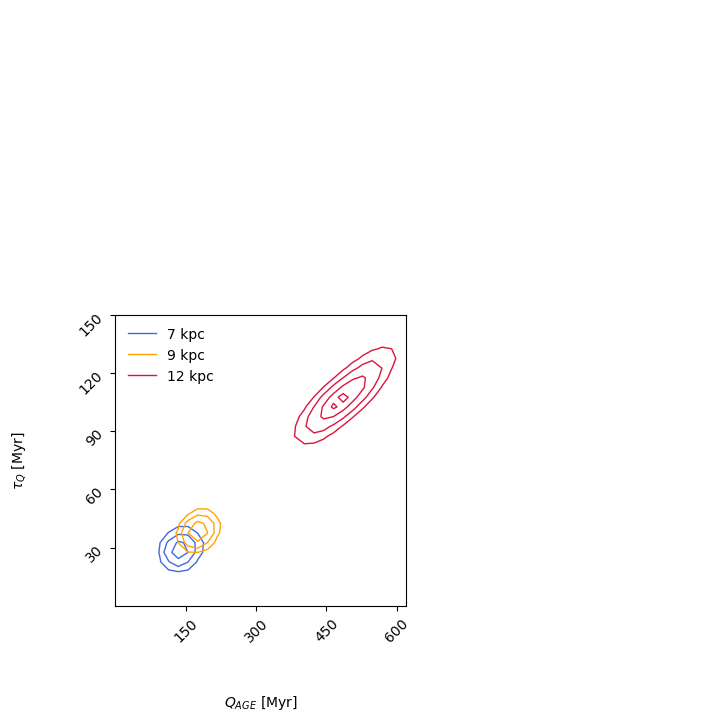

In [34]:
fig = multi_cornerplot(
    fitters=[res_spec_1_pacs_upp_lim, res_spec_2_pacs_upp_lim, res_spec_3_pacs_upp_lim],
    parameters=["TRUNCAGE", "TRUNCTAU"],
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"],
    legend_labels=["7 kpc", "9 kpc", "12 kpc"],
    colors=["royalblue", "orange", "crimson"]
)

plt.show()

fig = multi_corner_contours(
    fitters=[res_spec_1_pacs_upp_lim, res_spec_2_pacs_upp_lim, res_spec_3_pacs_upp_lim],
    parameters=["TRUNCAGE", "TRUNCTAU"], # ,"av"],
    ranges = [(0,620),(0,150)], #(0,0.2)],
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"], # "$A_V$"],
    legend_labels=["7 kpc", "9 kpc", "12 kpc"],
    colors=["royalblue", "orange", "crimson"],
    linewidths=1,
)

plt.show()


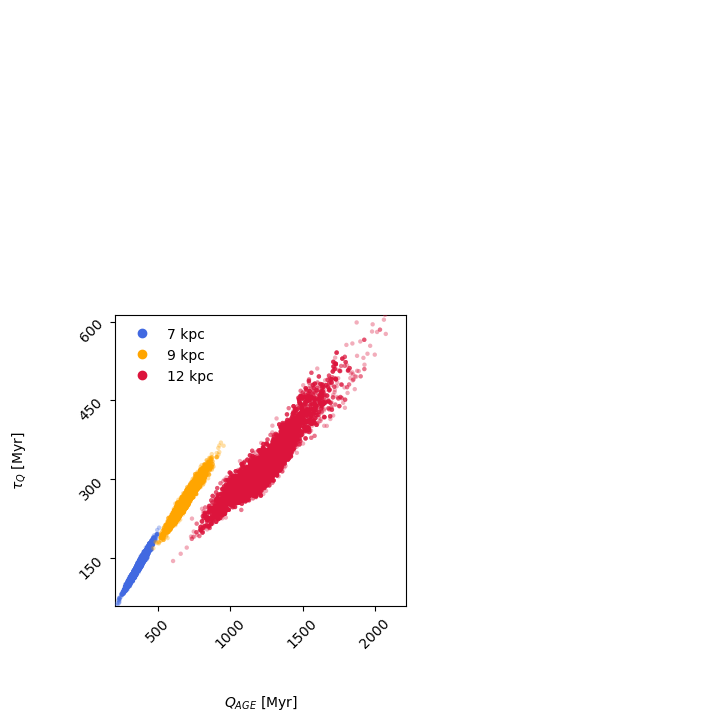

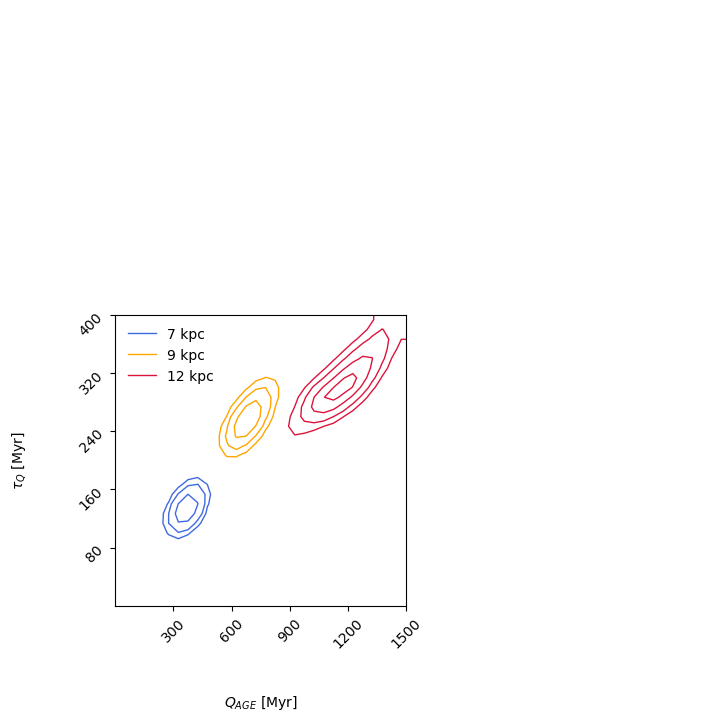

In [37]:
fig = multi_cornerplot(
    fitters=[res_spec_1_pacs_upp_lim_noemm, res_spec_2_pacs_upp_lim_noemm, res_spec_3_pacs_upp_lim_noemm],
    parameters=["TRUNCAGE", "TRUNCTAU"],
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"],
    legend_labels=["7 kpc", "9 kpc", "12 kpc"],
    colors=["royalblue", "orange", "crimson"]
)

plt.show()

fig = multi_corner_contours(
    fitters=[res_spec_1_pacs_upp_lim_noemm, res_spec_2_pacs_upp_lim_noemm, res_spec_3_pacs_upp_lim_noemm],
    parameters=["TRUNCAGE", "TRUNCTAU"], # ,"av"],
    ranges = [(0,1500),(0,400)], #(0,0.2)],
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"], # "$A_V$"],
    legend_labels=["7 kpc", "9 kpc", "12 kpc"],
    colors=["royalblue", "orange", "crimson"],
    linewidths=1,
)

plt.show()


In [10]:
params = res_spec_1.best_model()
bands = res_spec_1.bands

In [57]:
print(repr(params))

{'TRUNCAGE': 138.61335633472902, 'TRUNCTAU': 29.39949343698635, 'fesc': -0.00026909093320274385, 'ion_gas': -3.9990606502486763, 'age_gas': 0.5242887554838905, 'av': 0.029641161444719274, 'av_ext': 0.05516455887091225, 'alpha': 3.766165049863731, 'm_star': 8.9167736864441, 'vel_sys': 157.47355104383587, 'sigma_vel': 48.73845204893499, 'sigma_gas': 421.26029965056443, 'spec_noise_scale': 0.8709272767934713, 'redshift': 0.023974, 'luminosity_distance': 104}


In [101]:

params = {'TRUNCAGE': 138.61335633472902, 'TRUNCTAU': 29.39949343698635, 'fesc': -0.00026909093320274385, 'ion_gas': -3.9990606502486763, 'age_gas': 0.5242887554838905, 'av': 0.029641161444719274, 'av_ext': 0.05516455887091225, 'alpha': 3.766165049863731, 'm_star': 8.9167736864441, 'vel_sys': 157.47355104383587, 'sigma_vel': 48.73845204893499, 'sigma_gas': 421.26029965056443, 'spec_noise_scale': 0.8709272767934713, 'redshift': 0.023974, 'luminosity_distance': 104}




In [103]:
phot[0]

PhotometryTable(data={'galex_nuv': (0.028387410602288023, 0.001338558546496816), 'galex_fuv': (0.019169073147807563, 0.0009270254046495331), 'sdss_u': (0.09411367357124922, 0.004816764121368905), 'sdss_g': (0.30623675375861914, 0.004168889659262527), 'sdss_r': (0.4213420270847319, 0.005731913862384779), 'sdss_i': (0.5308333494484399, 0.0072196928805761075), 'sdss_z': (0.6480994057561001, 0.021187146404066926), 'hst_wfc3_uvis_f350lp': (0.43109997645662557, 0.006140937343969813), 'hst_wfc3_uvis_f600lp': (0.6089247206095323, 0.00867146226566051), 'spitzer_irac_1': (0.38693172429435624, 0.005508102511651342), 'spitzer_irac_2': (0.2396899957218369, 0.004789116775961939), 'spitzer_irac_3': (0.2274078300023752, 0.01671614664658884), 'spitzer_irac_4': (0.28199988806038606, 0.014896612988512878), 'herschel_pacs_70um': (4.755206937502995, 0.3821470062628701), 'herschel_pacs_100um': (11.61853223293199, 0.4454838127255576), 'herschel_pacs_160um': (3.0466359038841833, 0.07931684194843575)}, header=

In [104]:
phot[0].print()

,Value,Error,SNR
galex_nuv,0.028387,0.001339,21.207448
galex_fuv,0.019169,0.000927,20.678045
sdss_u,0.094114,0.004817,19.538776
sdss_g,0.306237,0.004169,73.457630
sdss_r,0.421342,0.005732,73.508088
sdss_i,0.530833,0.007220,73.525752
sdss_z,0.648099,0.021187,30.589273
hst_wfc3_uvis_f350lp,0.431100,0.006141,70.201006
hst_wfc3_uvis_f600lp,0.608925,0.008671,70.221688
spitzer_irac_1,0.386932,0.005508,70.247735


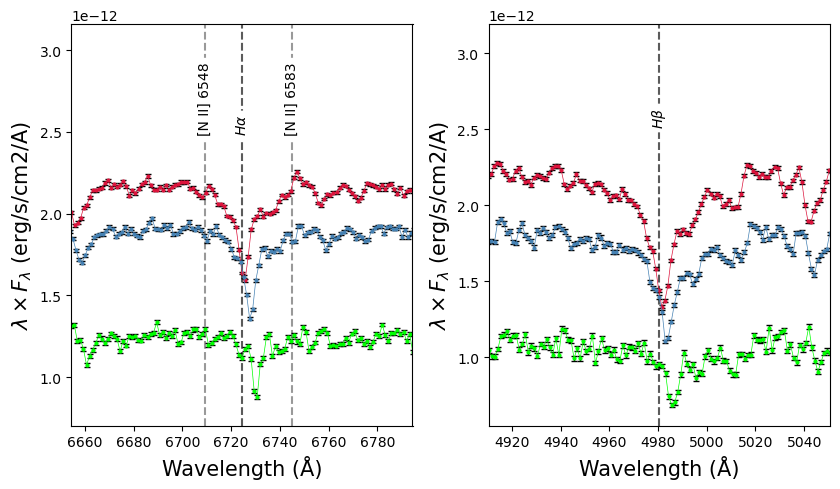

In [62]:
Spectrum().plot(figsize=(10,5),
                spectra=spectra, 
                per_wavelength=True, 
                phot=phot[0], #show_phot_legend=True,
                winf=4800,wsup=7000, 
\mathscr{U}                zoom_on_line=['Ha','Hb'],
                redshift = 0.0246, 
                color=['crimson','steelblue','lime'],
                ecolor='k',
                #ymin=5e-13, ymax= 1.5e-11, 
                #y_units='mJy',
                show_all_spectral_lines=True,show_top_spectral_lines=True,
                show_atmospheric_lines=True,show_spec_legend=False) 

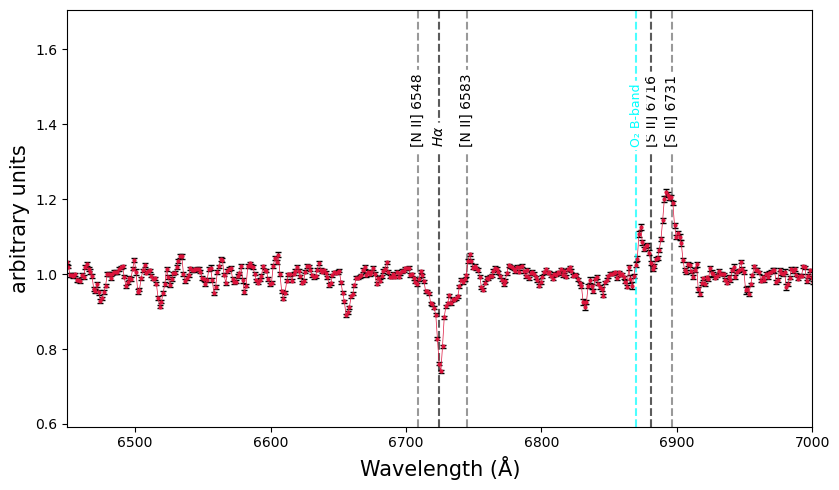

In [66]:
Spectrum().plot(figsize=(10,5),
                spectra=spectra[0], 
                per_wavelength=True, 
                remove_continuum=True,
                phot=phot[0], #show_phot_legend=True,
                winf=6450,wsup=7000, 
                redshift = 0.0246, 
                color=['crimson','steelblue','lime'],
                ecolor='k',
                #ymin=5e-13, ymax= 1.5e-11, 
                #y_units='mJy',
                show_all_spectral_lines=True,show_top_spectral_lines=True,
                show_atmospheric_lines=True,show_spec_legend=False) 



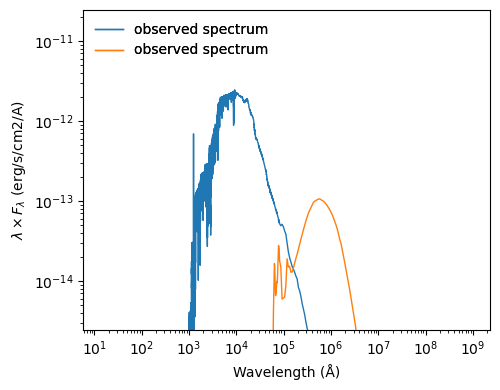

In [117]:
Spectrum().plot(spectra=[spec_plus.att_old_stellar_nebular,spec_plus.dust],per_wavelength=True)

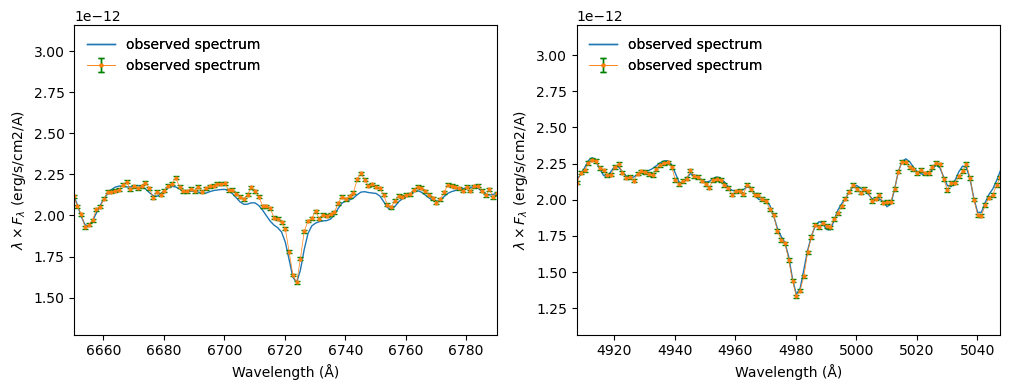

In [123]:
Spectrum().plot(spectra=[spec_plus.vel_convolved_obs_spec,spectra[0]],per_wavelength=True,winf=6600,wsup=6800,zoom_on_line=['Ha','Hb'])